In [201]:
"""
SED_plotting was getting too full so I added some plots here. 
Using the results from ProSpect I plot an improved version of bh mass vs stellar mass, 
stellar mass from stellar only fit against stellar+AGN fit, and
time evolution (with redshift).
Plotting morphological results from all_morphology tables is executed here.
"""

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from scipy.optimize import curve_fit, minimize
import astropy.units as u
from astropy.io import fits
from astropy.table import Table, vstack, join
from scipy.stats import ttest_rel
from IPython.display import display, Math
import math
import emcee
import corner

SERSIC_FILTERS = ["F444W", "F356W", "F277W"]

In [202]:
def straight_line(x, m, c):
   
    y=m*x + c
   
    return y

In [203]:
def red_chi_squared(y_values, y_uncertainties, model_data, dof):

  chi_squared = np.sum(((model_data - y_values) / y_uncertainties)**2)

  red_chi = chi_squared / (len(y_values) - dof)

  return red_chi

In [204]:
def weighted_reduced_chi_squared(y_obs, y_err_low, y_err_high, y_model, n_params,
                                  x_obs=None, x_err_low=None, x_err_high=None,
                                  gradient=None):
    """
    Calculate the reduced chi-squared for data with asymmetric uncertainties,
    optionally including x uncertainties projected onto y via the model gradient.

    Parameters
    ----------
    y_obs : array_like
        Observed y values.
    y_err_low : array_like
        Lower (negative) uncertainties on y.
    y_err_high : array_like
        Upper (positive) uncertainties on y.
    y_model : array_like
        Model predictions.
    n_params : int
        Number of fitted parameters.
    x_obs : array_like, optional
        Observed x values. Required if x_err_low/x_err_high are given.
    x_err_low : array_like, optional
        Lower (negative) uncertainties on x. If None, treated as zero.
    x_err_high : array_like, optional
        Upper (positive) uncertainties on x. If None, treated as zero.
    gradient : float, optional
        Local gradient of the model (dy/dx), used to project x uncertainty
        onto y. Required if x uncertainties are non-zero.

    Returns
    -------
    chi2_red : float
        Reduced chi-squared.
    """

    y_obs = np.asarray(y_obs, dtype=float)
    y_model = np.asarray(y_model, dtype=float)
    y_err_low = np.asarray(y_err_low, dtype=float)
    y_err_high = np.asarray(y_err_high, dtype=float)

    # Use the appropriate uncertainty depending on which side of the data
    sigma_y = np.where(y_model > y_obs, y_err_high, y_err_low)

    # Handle x uncertainties, if provided
    if x_err_low is None:
        x_err_low = np.zeros_like(y_obs)
    else:
        x_err_low = np.asarray(x_err_low, dtype=float)

    if x_err_high is None:
        x_err_high = np.zeros_like(y_obs)
    else:
        x_err_high = np.asarray(x_err_high, dtype=float)

    # If x errors are all zero, skip the x-error projection entirely —
    # this avoids requiring x_obs/gradient when there's nothing to project
    if np.all(x_err_low == 0) and np.all(x_err_high == 0):
        sigma = sigma_y
    else:
        if x_obs is None or gradient is None:
            raise ValueError("x_obs and gradient must be provided when x uncertainties are non-zero.")

        x_obs = np.asarray(x_obs, dtype=float)
        sigma_x = np.where(y_model > y_obs, x_err_high, x_err_low)

        # project x uncertainty onto y using the model gradient, combine in quadrature
        sigma = np.sqrt(sigma_y**2 + (gradient * sigma_x)**2)

    chi2 = np.sum(((y_obs - y_model) / sigma) ** 2)

    dof = len(y_obs) - n_params
    if dof <= 0:
        raise ValueError("Degrees of freedom must be positive.")

    chi2_red = chi2 / dof

    return chi2_red

In [205]:
def calculate_nmad(y, err_high, err_low, y_model):
    """
    Calculates the residuals between linear model and observed data.
    Normalises residuals by error.
    Calculates NMAD.
    """
    residuals = y - y_model

    sigma = np.where(
        residuals > 0,
        err_low,   # data lie above model
        err_high   # data lie below model
    )

    normalised_residuals = residuals / sigma

    nmad = 1.4826 * np.median( np.abs( normalised_residuals - np.median(normalised_residuals) ) )
    return nmad

In [206]:
def uncertainty_propagation(parameters, equation, n_samples=2000, batch_size=500):
    """
    Bootstrap-based uncertainty propagation.

    Parameters
    ----------
    parameters : list of tuples
        Each element is (Q16, Q50, Q84) for a parameter.
    equation : callable
        Function that accepts arrays of sampled parameters.
    n_samples : int
        Number of Monte Carlo samples.
    batch_size : int
        Number of samples to evaluate at once.

    Returns
    -------
    med : float
        Median of propagated quantity.
    upper_err : float
        +1 sigma (84th - median)
    lower_err : float
        -1 sigma (median - 16th)
    """

    samples = []
    # Stores Monte Carlo samples for each parameter

    # Bootstrap each parameter from its empirical percentiles
    for (q16, q50, q84) in parameters:

        # construct empirical distribution (no shape assumptions)
        x = np.array([q16, q50, q84]) # what the percentile values are
        p = np.array([0.16, 0.50, 0.84]) # defines the values as the percentiles we know them to be

        # bootstrap sampling via inverse CDF interpolation
        u = np.random.rand(n_samples) # Random percentiles of 0s and 1s
        s = np.interp(u, p, x) # Takes random percentile and interpolates with known quantities and returns the interpolated value

        samples.append(s)

    # shape: (n_params, n_samples)
    samples = np.array(samples) # converts list into array

    # transpose → (n_samples, n_params)
    samples = samples.T # now each row is (param1_i, param2_i,...)

    # Evaluate model in batches
    values = []

    for start in range(0, n_samples, batch_size):

        stop = min(start + batch_size, n_samples)

        batch_samples = samples[start:stop]

        batch_values = equation(batch_samples) # rows of output_i = equation(param1_i, param2_i,...)

        values.append(batch_values)

    values = np.concatenate(values)

    # Return percentiles
    med = np.percentile(values, 50)
    low = np.percentile(values, 16)
    high = np.percentile(values, 84)

    # RMS scatter of the Monte Carlo distribution
    scatter = np.std(values, ddof=1)

    return med, high - med, med - low

In [207]:
def format_value_uncertainty(value, upper_err, lower_err):
    """
    Format a value with asymmetric uncertainties using standard
    significant-figure rules (PDG rounding: 1 sig fig, or 2 if the
    leading digit is 1 or 2).

    Parameters
    ----------
    value : float
        Central value.
    upper_err : float
        +1 sigma uncertainty.
    lower_err : float
        -1 sigma uncertainty.

    Returns
    -------
    value_str, upper_str, lower_str : str
        Formatted value and uncertainties, all rounded to a consistent
        number of decimal places.
    """

    if upper_err == 0 and lower_err == 0:
        return f"{value:.3f}", "0", "0"

    def get_decimals(err):
        if err == 0:
            return 0
        exponent = math.floor(math.log10(abs(err)))
        first_digit = int(abs(err) / 10**exponent)
        sig_figs = 2 if first_digit in [1, 2] else 1
        return -(exponent - (sig_figs - 1))

    # decide precision using whichever error needs more decimal places,
    # so neither error gets rounded away to zero
    decimals = max(get_decimals(upper_err), get_decimals(lower_err))

    value_rounded = round(value, decimals)
    upper_rounded = round(upper_err, decimals)
    lower_rounded = round(lower_err, decimals)

    fmt = f"{{:.{max(decimals, 0)}f}}"

    return fmt.format(value_rounded), fmt.format(upper_rounded), fmt.format(lower_rounded)

In [208]:
def open_fits_table(file_path):
        # Open the FITS file
        with fits.open(file_path) as hdul:
            # Show the HDU structure
            hdul.info()

            # Usually the table is in extension 1
            data = hdul[1].data

        # Convert to an Astropy Table
        tbl = Table(data)
        #print("Number of objects = ", len(tbl))
        return tbl

In [209]:
def open_csv_table(path):

    table = Table.read(path, format="csv")
    
    # print("Table headers: ", table.colnames)
    
    """
    stellar_fields = ["ID", "RA","Dec","UV1500Best","StellarMassBest","StellarMassQ50", "StellarMassQ16","StellarMassQ84", "SFR10Best","SFR100Best","ZfinalBest"]
    
    stellar_AGN_fields = ["ID", "RA","Dec","AGNanBest","AGNlumQ50","UV1500AGNBest","UV1500Best","StellarMassBest","StellarMassQ50", "StellarMassQ16","StellarMassQ84", "SFR10Best","SFR100Best","ZfinalBest"]
    
    if path == "/nvme/scratch/work/alberttg/Summer_project/photoZ_bc03_snorm_astro_cat.csv":
    # Data for stellar only fitting
    # Could probably automate this 
        new_table = table[stellar_fields]
        # Data from fits with just stellar
        
    if path == "/nvme/scratch/work/alberttg/Summer_project/photoZ_bc03_snorm_fritz_astro_cat.csv":
    # Stellar and AGN fit data   
        new_table = table[stellar_AGN_fields]
    
    """
    return table

In [210]:
def _parse_err(err, n):
    """
    Normalize an error specification into (err_lo, err_hi) arrays of length n.

    Accepted forms for `err`:
      - None                            -> zeros (no error)
      - scalar or 1D array of length n  -> symmetric error (same as before)
      - [err_high, err_low]             -> asymmetric error; each of
        err_high/err_low can be a scalar (applied to all points) or a
        length-n array (per-point)

    Returned lo/hi are positive distances from the central value
    (lower bound = value - lo, upper bound = value + hi).
    """
    if err is None:
        return np.zeros(n), np.zeros(n)

    # Asymmetric: [err_high, err_low]
    if isinstance(err, (list, tuple)) and len(err) == 2:
        hi = np.asarray(err[0], dtype=float)
        lo = np.asarray(err[1], dtype=float)
        if hi.ndim == 0:
            hi = np.full(n, float(hi))
        if lo.ndim == 0:
            lo = np.full(n, float(lo))
        return lo.copy(), hi.copy()

    # Symmetric: scalar or array, same as before
    arr = np.asarray(err, dtype=float)
    if arr.ndim == 0:
        arr = np.full(n, float(arr))
    return arr.copy(), arr.copy()


def fit_linear_mcmc(x_in, y_in, x_err=None, y_err=None, x_pivot=None,
                     n_walkers=50, n_steps=10000, plot=False, save_path=None):
    """
    Bayesian linear fit y = m*(x - x_pivot) + c with intrinsic scatter,
    supporting asymmetric measurement errors in both x and y.

    x_err / y_err each accept:
      - None, a scalar, or a 1D array of length N (symmetric errors, same
        as before), OR
      - [err_high, err_low] for asymmetric errors, where each of
        err_high/err_low is a scalar (applied to every point) or a
        length-N array (per-point).

    Asymmetric-error handling
    --------------------------
    Each data point's error distribution is modeled as a split-normal
    (two-piece Gaussian): width `sigma_lo` below the measured value and
    `sigma_hi` above it. At every MCMC step, for each point we compare the
    model prediction to the data (delta = model - data) and pick the
    error side consistent with that comparison:
        delta >= 0  ->  use the "hi" error (model sits above the data)
        delta <  0  ->  use the "lo" error (model sits below the data)
    This is applied to both the y errors and the x errors (the latter
    projected into y-space via the slope, m^2 * xerr^2, as in the
    symmetric case). This is the standard practical approximation for
    asymmetric errors in a likelihood — it is exact only when the true
    error distribution really is split-normal, but works well in general
    and reduces to the ordinary symmetric-error likelihood when lo == hi.
    The intrinsic scatter term sigma_int is kept symmetric.
    """
    # --- Step 1: Data Cleaning & Pivot Handling ---
    x = np.asarray(x_in, dtype=float)
    y = np.asarray(y_in, dtype=float)
    n = len(x)

    xe_lo, xe_hi = _parse_err(x_err, n)
    ye_lo, ye_hi = _parse_err(y_err, n)

    xp = 0.0 if x_pivot is None else x_pivot

    mask = (
        np.isfinite(x) & np.isfinite(y)
        & np.isfinite(xe_lo) & np.isfinite(xe_hi)
        & np.isfinite(ye_lo) & np.isfinite(ye_hi)
    )

    # Guard against zero/negative error entries (keeps likelihood well-defined)
    xe_lo = np.where(xe_lo <= 0, 1e-10, xe_lo)
    xe_hi = np.where(xe_hi <= 0, 1e-10, xe_hi)
    ye_lo = np.where(ye_lo <= 0, 1e-10, ye_lo)
    ye_hi = np.where(ye_hi <= 0, 1e-10, ye_hi)

    x, y = x[mask], y[mask]
    xe_lo, xe_hi = xe_lo[mask], xe_hi[mask]
    ye_lo, ye_hi = ye_lo[mask], ye_hi[mask]

    if len(x) < 2:
        raise ValueError("Not enough finite data points.")

    # --- Step 2: Robust Initial Guess ---
    try:
        guess_m, guess_c = np.polyfit(x - xp, y, 1)
    except np.linalg.LinAlgError:
        guess_m, guess_c = 0.0, np.mean(y)

    guess_sigma = np.std(y - (guess_m * (x - xp) + guess_c))

    # --- Step 3: MCMC Functions (3 parameters: m, c, sigma_int) ---
    def log_likelihood(theta, x, y, xerr_lo, xerr_hi, yerr_lo, yerr_hi, xp):
        m, c, sigma_int = theta
        if sigma_int <= 0:
            return -np.inf

        model = m * (x - xp) + c
        delta = model - y  # positive => model above data

        y_sig = np.where(delta >= 0, yerr_hi, yerr_lo)
        x_sig = np.where(delta >= 0, xerr_hi, xerr_lo)

        sigma2 = y_sig**2 + (m**2 * x_sig**2) + sigma_int**2
        return -0.5 * np.sum(delta**2 / sigma2 + np.log(2 * np.pi * sigma2))

    def log_prior(theta):
        m, c, sigma_int = theta
        if -20.0 < m < 20.0 and -20.0 < c < 20.0 and 0.0 < sigma_int < 10.0:
            return 0.0
        return -np.inf

    def log_probability(theta, x, y, xerr_lo, xerr_hi, yerr_lo, yerr_hi, xp):
        lp = log_prior(theta)
        if not np.isfinite(lp):
            return -np.inf
        ll = log_likelihood(theta, x, y, xerr_lo, xerr_hi, yerr_lo, yerr_hi, xp)
        return lp + ll if np.isfinite(ll) else -np.inf

    # --- Step 4: Run MCMC ---
    ndim = 3
    initial = np.array([guess_m, guess_c, guess_sigma if guess_sigma > 0 else 0.1])
    pos = initial + 1e-4 * np.random.randn(n_walkers, ndim)

    sampler = emcee.EnsembleSampler(
        n_walkers, ndim, log_probability,
        args=(x, y, xe_lo, xe_hi, ye_lo, ye_hi, xp)
    )
    sampler.run_mcmc(pos, n_steps, progress=True)

    flat_samples = sampler.get_chain(discard=1000, thin=15, flat=True)

    x_range = np.linspace(x.min(), x.max(), 100)
    m_samples = flat_samples[:, 0]
    c_samples = flat_samples[:, 1]
    sig_samples = flat_samples[:, 2]

    models = m_samples[:, np.newaxis] * (x_range - xp) + c_samples[:, np.newaxis]

    m_med, c_med, sig_med = np.median(flat_samples, axis=0)
    lower_bound = np.percentile(models, 16, axis=0)
    upper_bound = np.percentile(models, 84, axis=0)

    # --- Step 5: Visualization ---
    if plot:
        plt.figure(figsize=(8, 6))
        print(f"Median slope: {m_med:.3f}, Intercept: {c_med:.3f}, Intrinsic Scatter: {sig_med:.3f}")

        # matplotlib expects asymmetric errors as [lower_distances, upper_distances]
        plt.errorbar(
            x, y,
            xerr=[xe_lo, xe_hi], yerr=[ye_lo, ye_hi],
            fmt=".k", alpha=0.4, label="Data", zorder=1
        )
        plt.fill_between(x_range, lower_bound, upper_bound, color="royalblue", alpha=0.3, label=r"1$\sigma$ Confidence")
        plt.plot(x_range, m_med * (x_range - xp) + c_med, color="darkblue", lw=2, label="Median Fit")
        plt.legend()
        if save_path:
            plt.savefig(save_path, dpi=150, bbox_inches="tight")
        plt.show()

        labels = ["Slope $m$", f"Intercept $c$ (at $x={xp}$)", r"$\sigma_{int}$"]
        corner.corner(flat_samples, labels=labels, truths=[m_med, c_med, sig_med], show_titles=True)
        plt.show()

    results = {
        "m_median": m_med,
        "c_median": c_med,
        "sig_int_median": sig_med,
        "m_16": np.percentile(flat_samples[:, 0], 16),
        "m_84": np.percentile(flat_samples[:, 0], 84),
        "c_16": np.percentile(flat_samples[:, 1], 16),
        "c_84": np.percentile(flat_samples[:, 1], 84),
        "sig_int_16": np.percentile(flat_samples[:, 2], 16),
        "sig_int_84": np.percentile(flat_samples[:, 2], 84),
        "x_pivot": xp,
    }

    return results

In [211]:
def plot_best_fit_with_uncertainty(ax, x, gradient, intercept,
                              gradient_upper_err,
                              gradient_lower_err,
                              intercept_upper_err,
                              intercept_lower_err,
                              label,
                              colour,
                              fill,
                              zorder,
                              line_kwargs=None,
                              band_kwargs=None,
                              ):
    """
    Plot a best-fit line and a shaded uncertainty region.

    Parameters
    ----------
    ax : matplotlib.axes.Axes
        Axis to plot on.
    x : array-like
        x-data (used to determine plotting range).
    gradient : float
        Best-fit slope.
    intercept : float
        Best-fit intercept.
    gradient_upper_err : float
        1-sigma upper uncertainty on slope.
    gradient_lower_err : float
        1-sigma lower uncertainty on slope.
    intercept_upper_err : float
        1-sigma upper uncertainty on intercept.
    intercept_lower_err : float
        1-sigma lower uncertainty on intercept.
    label : str
        Label for the fit.
    colour : str
        Colour of the line.
    zorder : float
        Order of when to plot the lines.
    fill : boolean
        True or False depending on if you want upper and lower best fit lines.
    """

    line_kwargs = {} if line_kwargs is None else line_kwargs.copy()
    line_kwargs.setdefault("color", colour)
    line_kwargs.setdefault("lw", 2)
    line_kwargs.setdefault("linestyle", "--")

    if band_kwargs is None:
        band_kwargs = {"color": colour, "alpha": 0.1}

    # Smooth x values for plotting
    xmin, xmax = np.min(x), np.max(x)
    pad = 0.01 * (xmax - xmin)
    x_plot = np.linspace(xmin - pad, xmax + pad, 500)

    # Best-fit line
    y = gradient * x_plot + intercept

    # Upper and lower bounds
    y_upper = ((gradient + gradient_upper_err) * x_plot
               + (intercept + intercept_upper_err))

    y_lower = ((gradient - gradient_lower_err) * x_plot
               + (intercept - intercept_lower_err))

    ax.plot(x_plot, y, label=label,zorder=zorder, **line_kwargs)

    if fill == True:
        ax.fill_between(x_plot, y_lower, y_upper, zorder=zorder, **band_kwargs)
    

In [212]:
def fit_straight_line_and_plot(
    x, x_upper_err, x_lower_err,
    y, y_upper_err, y_lower_err,
    plot_colours,
    ax,
    plot_points,
):

    if x_lower_err is None or x_upper_err is None:
        x_lower_err = np.zeros_like(x)
        x_upper_err = np.zeros_like(x)
    
    results = fit_linear_mcmc(x_in=x, y_in=y, 
                              x_err=[x_upper_err, x_lower_err], 
                              y_err=[y_upper_err, y_lower_err], 
                              x_pivot=None, n_walkers=50, n_steps=2000, plot=False, save_path=None)

    gradient = results["m_median"]
    gradient_upper_err = results["m_84"] - results["m_median"]
    gradient_lower_err = results["m_median"] - results["m_16"]
    intercept = results["c_median"]
    intercept_upper_err = results["c_84"] - results["c_median"]
    intercept_lower_err = results["c_median"] - results["c_16"]
    scatter_med = results["sig_int_median"]


    x_dummy_data = np.linspace(np.min(x),np.max(x),500)

    y_model = straight_line(x, gradient, intercept)

    weighted_red_chi = weighted_reduced_chi_squared(y_obs=y, y_err_low=y_upper_err, y_err_high=y_upper_err, y_model=y_model, n_params=2,
                                  x_obs=x, x_err_low=x_lower_err, x_err_high=x_upper_err,
                                  gradient=gradient)

    scatter = calculate_nmad(y, y_upper_err, y_lower_err, straight_line(x, gradient, intercept))

    if ax is not None:
        
        if plot_points==True:

            ax.errorbar(
                x,
                y,
                xerr=[x_lower_err, x_upper_err],
                yerr=[y_lower_err, y_upper_err],
                fmt='none',
                alpha=0.15,
                lw=0.8,
                zorder=2
            )

            ax.scatter(
                x,
                y,
                s=20,
                color=plot_colours,
                zorder=3
            )
        
        print("")
        print("For plot below: ")

        print(f"Reduced chi squared = {weighted_red_chi:.3g}")
        print(f"Scatter from fit = {scatter_med:.3f}")
        print(f"Scatter (NMAD of normalised residuals) = {scatter:.3f}")

    # t, p = ttest_rel(x, y)
    # print("p value = ",p)

    return ax, x_dummy_data, gradient, gradient_upper_err, gradient_lower_err, intercept, intercept_upper_err, intercept_lower_err, weighted_red_chi


In [213]:
def plot_stellar_masses(combined_table):
    """
    Plotting Q50 stellar mass from stars only against Q50 mass from stars and AGN.
    """
    # Stellar mass data:
    stellar_only_q16 = combined_table["StellarMassQ16_stellar"].data
    stellar_only_q50 = combined_table["StellarMassQ50_stellar"].data
    stellar_only_q84 = combined_table["StellarMassQ84_stellar"].data
    
    stellar_AGN_q16 = combined_table["StellarMassQ16_AGN"].data
    stellar_AGN_q50 = combined_table["StellarMassQ50_AGN"].data
    stellar_AGN_q84 = combined_table["StellarMassQ84_AGN"].data


    # Convert quantiles into asymmetric error bars
    yerr = [
        np.log10(stellar_only_q50) - np.log10(stellar_only_q16),
        np.log10(stellar_only_q84) - np.log10(stellar_only_q50)
    ]
    xerr = [
        np.log10(stellar_AGN_q50) - np.log10(stellar_AGN_q16),
        np.log10(stellar_AGN_q84) - np.log10(stellar_AGN_q50)
    ]
    
    fig, ax = plt.subplots(figsize=(10,10))

    (ax, stellar_dummy_data, gradient, gradient_upper_err, gradient_lower_err, intercept, intercept_upper_err, intercept_lower_err, weighted_red_chi
     ) = fit_straight_line_and_plot(
        x=np.log10(stellar_AGN_q50),
        x_upper_err=xerr[1],
        x_lower_err=xerr[0],
        y=np.log10(stellar_only_q50),
        y_upper_err=yerr[1],
        y_lower_err=yerr[0],
        plot_colours='C0',
        ax=ax,
        plot_points=True,
    )
    
    plot_best_fit_with_uncertainty(ax, stellar_dummy_data, gradient, intercept,
                              gradient_upper_err,
                              gradient_lower_err,
                              intercept_upper_err,
                              intercept_lower_err,
                              label='Line of best fit',
                              colour='red',
                              fill=False,
                              zorder=1,
                              )
    
    # 1:1 line
    mmin = min(np.min(np.log10(stellar_AGN_q50)),np.min(np.log10(stellar_only_q50)))
    mmax = max(np.max(np.log10(stellar_AGN_q50)),np.max(np.log10(stellar_only_q50)))

    ax.plot([mmin, mmax], [mmin, mmax], 'k--', lw=1, label='1:1')

    ax.set_ylabel(r'$\log_{10}(M_\star/M_\odot)$ (Stars only)',fontdict={'fontsize': 15})
    ax.set_xlabel(r'$\log_{10}(M_\star/M_\odot)$ (Stars + AGN)',fontdict={'fontsize': 15})
    ax.set_ylim(0.95 * mmin, 1.05 * mmax)
    ax.set_xlim(0.95 * mmin, 1.05 * mmax)
    ax.set_aspect('equal')
    ax.legend()

    plt.tight_layout()
    plt.show()
    
    return

In [214]:
def bhm_vs_sm_plot(stellar_table, stellar_AGN_table):
    """
    Plots log10(bh mass/ solar mass) against log10(stellar mass/ solar mass) 
    with line of best fit and best fit from Reines and Volonteri.

    Second half of function calculates and returns the log10(bhsmr) (Q16,Q50,Q84) and plots against log10(stellar mass/solar mass).
    """
    #Reines and Volonteri data:
    # Refer to Eq 5 of their paper
    RV_gradient = 1.05
    RV_gradient_uncertainty =0.11
    RV_intercept = 7.45 - RV_gradient*11
    RV_intercept_uncertainty = np.sqrt(0.08**2 + (11*0.11)**2)
    #------------------------------------------------------------------------------------------------------------------------------------------

    jades = np.asarray(["JADES-DR3-GS-East", "JADES-DR3-GS-North", "JADES-DR3-GS-South", "JADES-DR3-GS-West", "JADES-DR3-GN-Parallel", "JADES-DR3-GN-Medium", "JADES-DR3-GN-Deep"], dtype=str)
    primer =  np.asarray(["PRIMER-COSMOS","PRIMER-UDS"], dtype=str)
    ceers = np.asarray(["CEERSP1", "CEERSP2", "CEERSP3", "CEERSP4", "CEERSP5", "CEERSP6", "CEERSP7", "CEERSP8", "CEERSP9", "CEERSP10"], dtype=str)

    legend_elements = [
            Line2D([0], [0], marker='o', color='w',
                label='JADES',
                markerfacecolor='tab:blue',
                markeredgecolor='k',
                markersize=7),
                
            Line2D([0], [0], marker='o', color='w',
                label='CEERS',
                markerfacecolor='tab:purple',
                markeredgecolor='k',
                markersize=7),
                    
            Line2D([0], [0], marker='o', color='w',
                label='PRIMER',
                markerfacecolor='tab:gray',
                markeredgecolor='k',
                markersize=7)    ]
    
    def colours(survey):
        colours = np.empty(len(survey), dtype=object)
        for i, s in enumerate(survey):
            if s in jades:
                colours[i] = 'tab:blue'
            if s in ceers:
                colours[i] = 'tab:purple'
            if s in primer:
                colours[i] = 'tab:gray'
        return colours

    #------------------------------------------------------------------------------------------------------------------------------------------
    # Stellar+AGN
    survey_AGN = stellar_AGN_table["SURVEY"].data

    colours_AGN = colours(survey_AGN)

    stellar_mass_Q16_AGN = stellar_AGN_table["StellarMassQ16"].data
    stellar_mass_Q50_AGN = stellar_AGN_table["StellarMassQ50"].data
    stellar_mass_Q84_AGN = stellar_AGN_table["StellarMassQ84"].data
    
    bh_mass_AGN = stellar_AGN_table["BH_MASS"].data
    bh_mass_lower_err_AGN = stellar_AGN_table["BH_MASS_LOWER_ERR"].data
    bh_mass_upper_err_AGN = stellar_AGN_table["BH_MASS_UPPER_ERR"].data

    log_bh_mass_AGN = np.log10(bh_mass_AGN)
    log_bh_mass_lower_err_AGN = log_bh_mass_AGN - np.log10(np.abs(bh_mass_AGN - bh_mass_lower_err_AGN))
    log_bh_mass_upper_err_AGN = np.log10(bh_mass_AGN + bh_mass_upper_err_AGN) - log_bh_mass_AGN
    
    log_stellar_mass_AGN = np.log10(stellar_mass_Q50_AGN)
    log_stellar_mass_upper_err_AGN = np.log10(stellar_mass_Q84_AGN) - log_stellar_mass_AGN
    log_stellar_mass_lower_err_AGN = log_stellar_mass_AGN - np.log10(stellar_mass_Q16_AGN)
    #------------------------------------------------------------------------------------------------------------------------------------------
    # stellar only
    survey_stellar = stellar_table["SURVEY"].data

    colours_stellar = colours(survey_stellar)

    stellar_mass_Q16_stellar = stellar_table["StellarMassQ16"].data
    stellar_mass_Q50_stellar = stellar_table["StellarMassQ50"].data
    stellar_mass_Q84_stellar = stellar_table["StellarMassQ84"].data
    
    bh_mass_stellar = stellar_table["BH_MASS"].data
    bh_mass_lower_err_stellar = stellar_table["BH_MASS_LOWER_ERR"].data
    bh_mass_upper_err_stellar = stellar_table["BH_MASS_UPPER_ERR"].data

    log_bh_mass_stellar = np.log10(bh_mass_stellar)
    log_bh_mass_lower_err_stellar = log_bh_mass_stellar - np.log10(np.abs(bh_mass_stellar - bh_mass_lower_err_stellar))
    log_bh_mass_upper_err_stellar = np.log10(bh_mass_stellar + bh_mass_upper_err_stellar) - log_bh_mass_stellar
    
    log_stellar_mass_stellar = np.log10(stellar_mass_Q50_stellar)
    log_stellar_mass_upper_err_stellar = np.log10(stellar_mass_Q84_stellar) - log_stellar_mass_stellar
    log_stellar_mass_lower_err_stellar = log_stellar_mass_stellar - np.log10(stellar_mass_Q16_stellar)
    #------------------------------------------------------------------------------------------------------------------------------------------

    fig, ax = plt.subplots(figsize=(10,10))

    # Calculate the line of best fit for stellar only data:
    (_, stellar_x_dummy_data, stellar_gradient, stellar_gradient_upper_err, stellar_gradient_lower_err, stellar_intercept, stellar_intercept_upper_err, stellar_intercept_lower_err, stellar_weighted_red_chi
     ) = fit_straight_line_and_plot(
        x=log_stellar_mass_stellar,
        x_upper_err=log_stellar_mass_upper_err_stellar,
        x_lower_err=log_stellar_mass_lower_err_stellar,
        y=log_bh_mass_stellar,
        y_upper_err=log_bh_mass_upper_err_stellar,
        y_lower_err=log_bh_mass_lower_err_stellar,
        plot_colours=colours_stellar,
        ax=None,
        plot_points=False,
    )
    
    
    # Calculate the best fit for stellar+AGN data:
    (ax, AGN_x_dummy_data, AGN_gradient, AGN_gradient_upper_err, AGN_gradient_lower_err, AGN_intercept, AGN_intercept_upper_err, AGN_intercept_lower_err, AGN_weighted_red_chi
     ) = fit_straight_line_and_plot(
            x=log_stellar_mass_AGN,
            x_upper_err=log_stellar_mass_upper_err_AGN,
            x_lower_err=log_stellar_mass_lower_err_AGN,
            y=log_bh_mass_AGN,
            y_upper_err=log_bh_mass_upper_err_AGN,
            y_lower_err=log_bh_mass_lower_err_AGN,
            plot_colours=colours_AGN,
            ax=ax,
            plot_points=True,
        )
    
    # Make a plot of AGN best fit line
    plot_best_fit_with_uncertainty(
        ax,
        AGN_x_dummy_data,
        AGN_gradient,
        AGN_intercept,
        AGN_gradient_upper_err,
        AGN_gradient_lower_err,
        AGN_intercept_upper_err,
        AGN_intercept_lower_err,
        "Stellar+AGN fit",
        "red",
        fill=True,
        zorder=3,
    )
    
    # Plot equation of stellar best fit but using AGN stellar masses
    
    plot_best_fit_with_uncertainty(
        ax,
        AGN_x_dummy_data,
        stellar_gradient,
        stellar_intercept,
        stellar_gradient_upper_err,
        stellar_gradient_lower_err,
        stellar_intercept_upper_err,
        stellar_intercept_lower_err,
        "Stellar fit",
        "blue",
        fill=False,
        zorder=2
    )
    
    # Plot RV line of best fit on AGN stellar masses
    plot_best_fit_with_uncertainty(
        ax,
        AGN_x_dummy_data,
        RV_gradient,
        RV_intercept,
        RV_gradient_uncertainty,
        RV_gradient_uncertainty,
        RV_intercept_uncertainty,
        RV_intercept_uncertainty,
        "Reines & Volonteri",
        "black",
        fill=True,
        zorder=1,
    )

    ax.set_ylabel(r'$\log_{10}(M_{BH}/M_\odot)$ (Black Hole Mass)',fontdict={'fontsize': 15})
    ax.set_xlabel(r'$\log_{10}(M_\star/M_\odot)$ (Stellar Mass Q50)',fontdict={'fontsize': 15})
    plt.xlim(5,12)
    
    line_legend = ax.legend(loc='upper right')
    ax.legend(handles=legend_elements, title="Survey", loc='upper left')
    ax.add_artist(line_legend)
    plt.show()

    
    print("")
    print("Reines & Volonteri equation: ")
    display(Math(
        rf"$\log_{{10}}(M_{{\rm BH}}/M_\odot)"
        rf" = ({RV_gradient} \pm {RV_gradient_uncertainty})\,"
        rf"\log_{{10}}(M_\star/M_\odot)"
        rf" + ({RV_intercept} \pm {RV_intercept_uncertainty})$"
    ))

    grad_AGN, grad_upper_err_AGN, grad_lower_err_AGN = format_value_uncertainty(
        AGN_gradient, AGN_gradient_upper_err, AGN_gradient_lower_err
    )
    inter_AGN, inter_upper_err_AGN, inter_lower_err_AGN = format_value_uncertainty(
        AGN_intercept, AGN_intercept_upper_err, AGN_intercept_lower_err
    )

    print("Line of best fit equation for AGN fit: ")
    display(Math(
        rf"$\log_{{10}}(M_{{\rm BH}}/M_\odot)"
        rf" = ({grad_AGN}^{{+{grad_upper_err_AGN}}}_{{-{grad_lower_err_AGN}}})\,"
        rf"\log_{{10}}(M_\star/M_\odot)"
        rf" + ({inter_AGN}^{{+{inter_upper_err_AGN}}}_{{-{inter_lower_err_AGN}}})$"
    ))


    grad_stellar, grad_upper_err_stellar, grad_lower_err_stellar = format_value_uncertainty(
        stellar_gradient, stellar_gradient_upper_err, stellar_gradient_lower_err
    )
    inter_stellar, inter_upper_err_stellar, inter_lower_err_stellar = format_value_uncertainty(
        stellar_intercept, stellar_intercept_upper_err, stellar_intercept_lower_err
    )

    print("Line of best fit equation for stellar only fit: ")
    display(Math(
        rf"$\log_{{10}}(M_{{\rm BH}}/M_\odot)"
        rf" = ({grad_stellar}^{{+{grad_upper_err_stellar}}}_{{-{grad_lower_err_stellar}}})\,"
        rf"\log_{{10}}(M_\star/M_\odot)"
        rf" + ({inter_stellar}^{{+{inter_upper_err_stellar}}}_{{-{inter_lower_err_stellar}}})$"
    ))


In [215]:
def bhm_vs_morph(table):
    """
    Black hole mass vs r_eff and vs n.
    """
    bh_mass = table["BH_MASS"].data
    bh_mass_lower_err = table["BH_MASS_LOWER_ERR"].data
    bh_mass_upper_err = table["BH_MASS_UPPER_ERR"].data

    log_bh_mass = np.log10(bh_mass)
    log_bh_mass_lower_err = log_bh_mass - np.log10(np.abs(bh_mass - bh_mass_lower_err))
    log_bh_mass_upper_err = np.log10(bh_mass + bh_mass_upper_err) - log_bh_mass

    fig_r, ax_r = plt.subplots(figsize=(10,10))

    for filt in SERSIC_FILTERS:
    
        r_eff = table[f"best_{filt}_r_eff_mean"].data
        r_eff_err = table[f"best_{filt}_r_eff_sd"].data

        if filt == "F444W":
            _ax_ = ax_r
            _plot_ = True
            colour = 'red'
        if filt == "F356W":
            _ax_ = ax_r
            _plot_ = True
            colour = 'orange'
        if filt == "F277W":
            _ax_ = ax_r
            _plot_ = True
            colour = 'green'

        # Calculate the line of best fit for data:
        (_, r_dummy_data, r_gradient, r_gradient_upper_err, r_gradient_lower_err,
         r_intercept, r_intercept_upper_err, r_intercept_lower_err, r_weighted_red_chi
            ) = fit_straight_line_and_plot(
            x=r_eff,
            x_upper_err=r_eff_err,
            x_lower_err=r_eff_err,
            y=log_bh_mass,
            y_upper_err=log_bh_mass_upper_err,
            y_lower_err=log_bh_mass_lower_err,
            plot_colours=colour,
            ax=_ax_,
            plot_points=_plot_,
        )

        r_grad, r_grad_upper_err, r_grad_lower_err = format_value_uncertainty(
            r_gradient, r_gradient_upper_err, r_gradient_lower_err
        )
        r_inter, r_inter_upper_err, r_inter_lower_err = format_value_uncertainty(
            r_intercept, r_intercept_upper_err, r_intercept_lower_err
        )
        print(rf"{filt} Gradient = ${r_grad}^{{+{r_grad_upper_err}}}_{{-{r_grad_lower_err}}}$")
        print(rf"{filt} Intercept = ${r_inter}^{{+{r_inter_upper_err}}}_{{-{r_inter_lower_err}}}$")
        
        # Plot best fit line for all data:
        plot_best_fit_with_uncertainty(
            ax_r,
            r_dummy_data,
            r_gradient,
            r_intercept,
            r_gradient_upper_err,
            r_gradient_lower_err,
            r_intercept_upper_err,
            r_intercept_lower_err,
            f"{filt} line of best fit",
            colour,
            fill=False,
            zorder=1,
            line_kwargs=None,
            band_kwargs=None
        )
        
    
    ax_r.set_ylabel(r'$\log_{10}(M_{BH}/M_\odot)$ (Black Hole Mass)',fontdict={'fontsize': 15})
    ax_r.set_xlabel(r'$r_{eff} / kpc$ (Half-light radius)',fontdict={'fontsize': 15})
    ax_r.legend(loc='upper right')
    plt.show()

    #--------------------------------------------------------------------------------------------------------------
    fig_n, ax_n = plt.subplots(figsize=(10,10))

    for filt in SERSIC_FILTERS:
    
        n = table[f"best_{filt}_n_mean"].data
        n_err = table[f"best_{filt}_n_sd"].data

        if filt == "F444W":
            _ax_ = ax_n
            _plot_ = True
            colour = 'red'
        if filt == "F356W":
            _ax_ = ax_n
            _plot_ = True
            colour = 'orange'
        if filt == "F277W":
            _ax_ = ax_n
            _plot_ = True
            colour = 'green'

        # Calculate the line of best fit for data:
        (_, n_dummy_data, n_gradient, n_gradient_upper_err, n_gradient_lower_err,
         n_intercept, n_intercept_upper_err, n_intercept_lower_err, n_weighted_red_chi
            ) = fit_straight_line_and_plot(
            x=n,
            x_upper_err=n_err,
            x_lower_err=n_err,
            y=log_bh_mass,
            y_upper_err=log_bh_mass_upper_err,
            y_lower_err=log_bh_mass_lower_err,
            plot_colours=colour,
            ax=_ax_,
            plot_points=_plot_,
        )

        n_grad, n_grad_upper_err, n_grad_lower_err = format_value_uncertainty(
            n_gradient, n_gradient_upper_err, n_gradient_lower_err
        )
        n_inter, n_inter_upper_err, n_inter_lower_err = format_value_uncertainty(
            n_intercept, n_intercept_upper_err, n_intercept_lower_err
        )
        print(rf"{filt} Gradient = ${n_grad}^{{+{r_grad_upper_err}}}_{{-{n_grad_lower_err}}}$")
        print(rf"{filt} Intercept = ${n_inter}^{{+{r_inter_upper_err}}}_{{-{n_inter_lower_err}}}$")
        
        # Plot best fit line for all data:
        plot_best_fit_with_uncertainty(
            ax_n,
            n_dummy_data,
            n_gradient,
            n_intercept,
            n_gradient_upper_err,
            n_gradient_lower_err,
            n_intercept_upper_err,
            n_intercept_lower_err,
            f"{filt} line of best fit",
            colour,
            fill=False,
            zorder=1,
            line_kwargs=None,
            band_kwargs=None
        )
        
    
    ax_n.set_ylabel(r'$\log_{10}(M_{BH}/M_\odot)$ (Black Hole Mass)',fontdict={'fontsize': 15})
    ax_n.set_xlabel(r'Sersic index',fontdict={'fontsize': 15})
    ax_n.legend(loc='upper right')
    plt.show()

In [216]:
def bhsmr_vs_morph(table):
    """
    Black hole mass vs r_eff and vs n.
    """
    bh_mass = table["bhsmr"].data
    bh_mass_lower_err = table["bhsmr_lower_err"].data
    bh_mass_upper_err = table["bhsmr_upper_err"].data

    log_bh_mass = np.log10(bh_mass)
    log_bh_mass_lower_err = log_bh_mass - np.log10(np.abs(bh_mass - bh_mass_lower_err))
    log_bh_mass_upper_err = np.log10(bh_mass + bh_mass_upper_err) - log_bh_mass

    fig_r, ax_r = plt.subplots(figsize=(10,10))

    for filt in SERSIC_FILTERS:
    
        r_eff = table[f"best_{filt}_r_eff_mean"].data
        r_eff_err = table[f"best_{filt}_r_eff_sd"].data

        if filt == "F444W":
            _ax_ = ax_r
            _plot_ = True
            colour = 'red'
        if filt == "F356W":
            _ax_ = ax_r
            _plot_ = True
            colour = 'orange'
        if filt == "F277W":
            _ax_ = ax_r
            _plot_ = True
            colour = 'green'

        # Calculate the line of best fit for data:
        (_, r_dummy_data, r_gradient, r_gradient_upper_err, r_gradient_lower_err,
         r_intercept, r_intercept_upper_err, r_intercept_lower_err, r_weighted_red_chi
            ) = fit_straight_line_and_plot(
            x=r_eff,
            x_upper_err=r_eff_err,
            x_lower_err=r_eff_err,
            y=log_bh_mass,
            y_upper_err=log_bh_mass_upper_err,
            y_lower_err=log_bh_mass_lower_err,
            plot_colours=colour,
            ax=_ax_,
            plot_points=_plot_,
        )

        r_grad, r_grad_upper_err, r_grad_lower_err = format_value_uncertainty(
            r_gradient, r_gradient_upper_err, r_gradient_lower_err
        )
        r_inter, r_inter_upper_err, r_inter_lower_err = format_value_uncertainty(
            r_intercept, r_intercept_upper_err, r_intercept_lower_err
        )
        print(rf"{filt} Gradient = ${r_grad}^{{+{r_grad_upper_err}}}_{{-{r_grad_lower_err}}}$")
        print(rf"{filt} Intercept = ${r_inter}^{{+{r_inter_upper_err}}}_{{-{r_inter_lower_err}}}$")
        
        # Plot best fit line for all data:
        plot_best_fit_with_uncertainty(
            ax_r,
            r_dummy_data,
            r_gradient,
            r_intercept,
            r_gradient_upper_err,
            r_gradient_lower_err,
            r_intercept_upper_err,
            r_intercept_lower_err,
            f"{filt} line of best fit",
            colour,
            fill=False,
            zorder=1,
            line_kwargs=None,
            band_kwargs=None
        )
        
    
    ax_r.set_ylabel(r'$\log_{10}(M_{BH}/M_\odot)$ (Black Hole Mass)',fontdict={'fontsize': 15})
    ax_r.set_xlabel(r'$r_{eff} / kpc$ (Half-light radius)',fontdict={'fontsize': 15})
    ax_r.legend(loc='upper right')
    plt.show()

    #--------------------------------------------------------------------------------------------------------------
    fig_n, ax_n = plt.subplots(figsize=(10,10))

    for filt in SERSIC_FILTERS:
    
        n = table[f"best_{filt}_n_mean"].data
        n_err = table[f"best_{filt}_n_sd"].data

        if filt == "F444W":
            _ax_ = ax_n
            _plot_ = True
            colour = 'red'
        if filt == "F356W":
            _ax_ = ax_n
            _plot_ = True
            colour = 'orange'
        if filt == "F277W":
            _ax_ = ax_n
            _plot_ = True
            colour = 'green'

        # Calculate the line of best fit for data:
        (_, n_dummy_data, n_gradient, n_gradient_upper_err, n_gradient_lower_err,
         n_intercept, n_intercept_upper_err, n_intercept_lower_err, n_weighted_red_chi
            ) = fit_straight_line_and_plot(
            x=n,
            x_upper_err=n_err,
            x_lower_err=n_err,
            y=log_bh_mass,
            y_upper_err=log_bh_mass_upper_err,
            y_lower_err=log_bh_mass_lower_err,
            plot_colours=colour,
            ax=_ax_,
            plot_points=_plot_,
        )

        n_grad, n_grad_upper_err, n_grad_lower_err = format_value_uncertainty(
            n_gradient, n_gradient_upper_err, n_gradient_lower_err
        )
        n_inter, n_inter_upper_err, n_inter_lower_err = format_value_uncertainty(
            n_intercept, n_intercept_upper_err, n_intercept_lower_err
        )
        print(rf"{filt} Gradient = ${n_grad}^{{+{r_grad_upper_err}}}_{{-{n_grad_lower_err}}}$")
        print(rf"{filt} Intercept = ${n_inter}^{{+{r_inter_upper_err}}}_{{-{n_inter_lower_err}}}$")
        
        # Plot best fit line for all data:
        plot_best_fit_with_uncertainty(
            ax_n,
            n_dummy_data,
            n_gradient,
            n_intercept,
            n_gradient_upper_err,
            n_gradient_lower_err,
            n_intercept_upper_err,
            n_intercept_lower_err,
            f"{filt} line of best fit",
            colour,
            fill=False,
            zorder=1,
            line_kwargs=None,
            band_kwargs=None
        )
        
    
    ax_n.set_ylabel(r'$\log_{10}(M_{BH}/M_\odot)$ (Black Hole Mass)',fontdict={'fontsize': 15})
    ax_n.set_xlabel(r'Sersic index',fontdict={'fontsize': 15})
    ax_n.legend(loc='upper right')
    plt.show()

In [217]:
def plot_against_z(z, y, y_lower_err, y_upper_err, plot_colours, mask, y_label, log, fill, ax):
    """
    Plots a given y parameter against redshift and fits best line.
    """

    if log == True:
        y_lower_err = np.log10(y) - np.log10(np.abs(y - y_lower_err)) #log10
        y_upper_err = np.log10(y + y_upper_err) - np.log10(y) #log10
        y = np.log10(y) #log10

        y_label = r'$\log_{10}$'+ y_label 

    if mask is not None:
        y = y[mask]
        y_lower_err = y_lower_err[mask]
        y_upper_err = y_upper_err[mask]
        z = z[mask]

    if ax is None:

        fig, ax = plt.subplots(figsize=(10,10))

    (ax, z_dummy_data, gradient, gradient_upper_err, gradient_lower_err,
     intercept, intercept_upper_err, intercept_lower_err, weighted_red_chi
     ) = fit_straight_line_and_plot(
            x=z,
            x_upper_err=None,
            x_lower_err=None,
            y=y,
            y_upper_err=y_upper_err,
            y_lower_err=y_lower_err,
            plot_colours=plot_colours,
            ax=ax,
            plot_points=True,
        )
    
    # Make a plot of AGN best fit line
    plot_best_fit_with_uncertainty(
        ax,
        z_dummy_data,
        gradient,
        intercept,
        gradient_upper_err,
        gradient_lower_err,
        intercept_upper_err,
        intercept_lower_err,
        "Line of best fit",
        "red",
        fill=fill,
        zorder=1,
        line_kwargs=None,
        band_kwargs=None
    )
    ax.set_xlabel(r'$z$ (Spectroscopic redshift)',fontdict={'fontsize': 15})
    ax.set_ylabel(y_label,fontdict={'fontsize': 15})
    ax.legend()
    plt.show()

    grad, grad_upper_err, grad_lower_err = format_value_uncertainty(gradient, gradient_upper_err, gradient_lower_err)
    inter, inter_upper_err, inter_lower_err = format_value_uncertainty(intercept, intercept_upper_err, intercept_lower_err)

    display(Math(rf" \text{{Gradient}} = ({grad}^{{+{grad_upper_err}}}_{{-{grad_lower_err}}})"))
    display(Math(rf" \text{{Intercept}} = ({inter}^{{+{inter_upper_err}}}_{{-{inter_lower_err}}})"))

    return ax, grad, grad_upper_err, grad_lower_err, inter, inter_upper_err, inter_lower_err


In [218]:
def time_evolution_SED_data(table):

    z = np.asarray(table["REDSHIFT"].data, dtype=float)

    bh_mass = table["BH_MASS"].data
    bh_mass_lower_err = table["BH_MASS_LOWER_ERR"].data
    bh_mass_upper_err = table["BH_MASS_UPPER_ERR"].data
    plot_against_z(z, bh_mass, bh_mass_lower_err, bh_mass_upper_err, plot_colours='C0', mask=None, y_label=r"$(M_{BH}/M_\odot$)", log=True, fill=True, ax=None)

    stellar_mass_Q16 = table["StellarMassQ16"].data
    stellar_mass_Q50 = table["StellarMassQ50"].data
    stellar_mass_Q84 = table["StellarMassQ84"].data
    stellar_mass_lower_err = np.abs(stellar_mass_Q50 - stellar_mass_Q16)
    stellar_mass_upper_err = np.abs(stellar_mass_Q84 - stellar_mass_Q50)
    #plot_against_z(z, stellar_mass_Q50, stellar_mass_lower_err, stellar_mass_upper_err, plot_colours='C0', mask=None, y_label=r"$(M_\star/M_\odot)$", log=True, fill=True, ax=None)


    bhsmr = np.asarray(table["bhsmr"].data)
    bhsmr_upper_err = np.asarray(table["bhsmr_upper_err"].data)
    bhsmr_lower_err = np.asarray(table["bhsmr_lower_err"].data)
    plot_against_z(z, bhsmr, bhsmr_lower_err, bhsmr_upper_err, plot_colours='C0', mask=None, y_label=r"$\log_10(M_{BH}/M_\star)$ BHSMR", log=False, fill=True, ax=None)


    AGNfrac_Q16 = np.asarray(table["AGN_Dale_fracQ16"].data)
    AGNfrac_Q50 = np.asarray(table["AGN_Dale_fracQ50"].data)
    AGNfrac_Q84 = np.asarray(table["AGN_Dale_fracQ84"].data)
    AGNfrac_lower_err = AGNfrac_Q50 - AGNfrac_Q16
    AGNfrac_upper_err = AGNfrac_Q84 - AGNfrac_Q50
    plot_against_z(z, AGNfrac_Q50, AGNfrac_lower_err, AGNfrac_upper_err, plot_colours='C0', mask=None, y_label='AGN fraction', log=False, fill=True, ax=None)


    AGNlum_Q16 = table["AGNlumQ16"].data
    AGNlum_Q50 = table["AGNlumQ50"].data
    AGNlum_Q84 = table["AGNlumQ84"].data
    AGNlum_lower_err = AGNlum_Q50 - AGNlum_Q16
    AGNlum_upper_err = AGNlum_Q84 - AGNlum_Q50
    plot_against_z(z, AGNlum_Q50, AGNlum_lower_err, AGNlum_upper_err, plot_colours='C0', mask=None, y_label=r'$(L_{AGN}/erg s^{-1})$ bolometric AGN luminosity', log=True, fill=True, ax=None)


    sfr10_Q50 = table["SFR10Q50"].data
    sfr10_Q16 = table["SFR10Q16"].data
    sfr10_Q84 = table["SFR10Q84"].data
    sfr10_lower_err = sfr10_Q50 - sfr10_Q16
    sfr10_upper_err = sfr10_Q84 - sfr10_Q50
    plot_against_z(z, sfr10_Q50, sfr10_lower_err, sfr10_upper_err, plot_colours='C0', mask=sfr10_Q50>=1, y_label=r"$(SFR10 / M_\odot yr^{-1})$", log=True, fill=True, ax=None)

    sfr100_Q50 = table["SFR100Q50"].data
    sfr100_Q16 = table["SFR100Q16"].data
    sfr100_Q84 = table["SFR100Q84"].data
    sfr100_lower_err = sfr100_Q50 - sfr100_Q16
    sfr100_upper_err = sfr100_Q84 - sfr100_Q50
    plot_against_z(z, sfr100_Q50, sfr100_lower_err, sfr100_upper_err, plot_colours='C0', mask=sfr100_Q50>=1, y_label=r"$(SFR100 / M_\odot yr^{-1})$", log=True, fill=True, ax=None)


    sSFR10 = table["sSFR10"]
    sSFR10_upper_err = table["sSFR10_upper_err"]
    sSFR10_lower_err = table["sSFR10_lower_err"]
    plot_against_z(z, sSFR10, sSFR10_lower_err, sSFR10_upper_err, plot_colours='C0', mask=np.log10(sSFR10)>=-13, y_label=r"$(sSFR10 / M_\odot yr^{-1})$", log=True, fill=True, ax=None)


    sSFR100 = table["sSFR100"]
    sSFR100_upper_err = table["sSFR100_upper_err"] 
    sSFR100_lower_err = table["sSFR100_lower_err"]
    plot_against_z(z, sSFR100, sSFR100_lower_err, sSFR100_upper_err, plot_colours='C0', mask=np.log10(sSFR100)>=-13, y_label=r"$(sSFR100 / M_\odot yr^{-1})$", log=True, fill=True, ax=None)

In [219]:
def time_evolution_morphology(table):
    """
    Plotting sersic indices, and r_eff against z in three filters.
    """
    z = np.asarray(table["REDSHIFT"].data, dtype=float)

    for filt in SERSIC_FILTERS:

        r_eff = table[f"best_{filt}_r_eff_mean"].data
        r_eff_err = table[f"best_{filt}_r_eff_sd"].data
        ax_r = plot_against_z(z, r_eff, r_eff_err, r_eff_err, plot_colours="C0", mask=None, y_label=r"$r_{eff}/kpc$ Half-light radius in {filt}", log=False, fill=True, ax=None)[0]

        # Plot r propto (1+z)^-1
        A = np.median(r_eff * (1 + z))

        z_line = np.linspace(z.min(), z.max(), 200)
        ax_r.plot(z_line, A / (1 + z_line), '--k', label=r'$\propto (1+z)$')


        n = table[f"best_{filt}_n_mean"].data
        n_err = table[f"best_{filt}_n_sd"].data
        ax = plot_against_z(z, n, n_err, n_err, plot_colours='C0', mask=None, y_label=r"Sersic index in {filt}", log=False, fill=True, ax=None)[0]

        n_morph = table[f"{filt}_nFit2D"].data
        ax.scatter(x=z, y=n_morph, label='Morphometryka data', fmt='x', color='black')
        ax.legend()
        plt.show()



Filename: /nvme/scratch/work/alberttg/Summer_project/Data_products/ProSpect_stellar_only_galaxy_table.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU       4   ()      
  1                1 BinTableHDU    899   143R x 442C   [D, D, D, D, D, D, D, D, D, D, D, D, D, K, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, K, K, K, K, K, K, K, K, D, D, D, D, D, D, D, D, K, K, K, K, K, K, K, K, K, D, D, D, D, D, D, D, D, D, D, D, D, D, K, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, K, K, K, K, K, K, K, K, D, D, D, D, D, D, D, D, K, K, K, K, K, K, K, K, K, D, D, D, D, D, D, D, D, D, D, D, D, D, K, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, K, K, K, K, K, K, K, K, D, D, D, D, D, D, D, D, K, K, K, K, K, K, K, K, K, D, D, D, D, D, D, D, D, D, D, D, D, D, K, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, K, K, K, K, K, K, K, K, D, D, D, D, D, D, D, D, K, K, K, K, K, K, K, K, K, D, D, D, D, D, D, D, D, D, D, D, D, D, 

100%|██████████| 2000/2000 [00:05<00:00, 339.58it/s]
/nvme/scratch/software/anaconda3/envs/lewi_galfind/lib/python3.9/site-packages/numpy/core/fromnumeric.py:784: UserWarning: Warning: 'partition' will ignore the 'mask' of the MaskedArray.
  a.partition(kth, axis=axis, kind=kind, order=order)



For plot below: 
Reduced chi squared = 1.34e+04
Scatter from fit = 0.898
Scatter (NMAD of normalised residuals) = 9.573
F444W Gradient = $-0.09^{+0.09}_{-0.09}$
F444W Intercept = $6.46^{+0.12}_{-0.11}$


100%|██████████| 2000/2000 [00:06<00:00, 303.32it/s]



For plot below: 
Reduced chi squared = 1.12e+04
Scatter from fit = 0.900
Scatter (NMAD of normalised residuals) = 9.424
F356W Gradient = $-0.15^{+0.11}_{-0.12}$
F356W Intercept = $6.52^{+0.13}_{-0.13}$


100%|██████████| 2000/2000 [00:06<00:00, 302.52it/s]



For plot below: 
Reduced chi squared = 7.82e+04
Scatter from fit = 0.902
Scatter (NMAD of normalised residuals) = 9.673
F277W Gradient = $0.01^{+0.11}_{-0.11}$
F277W Intercept = $6.38^{+0.14}_{-0.14}$


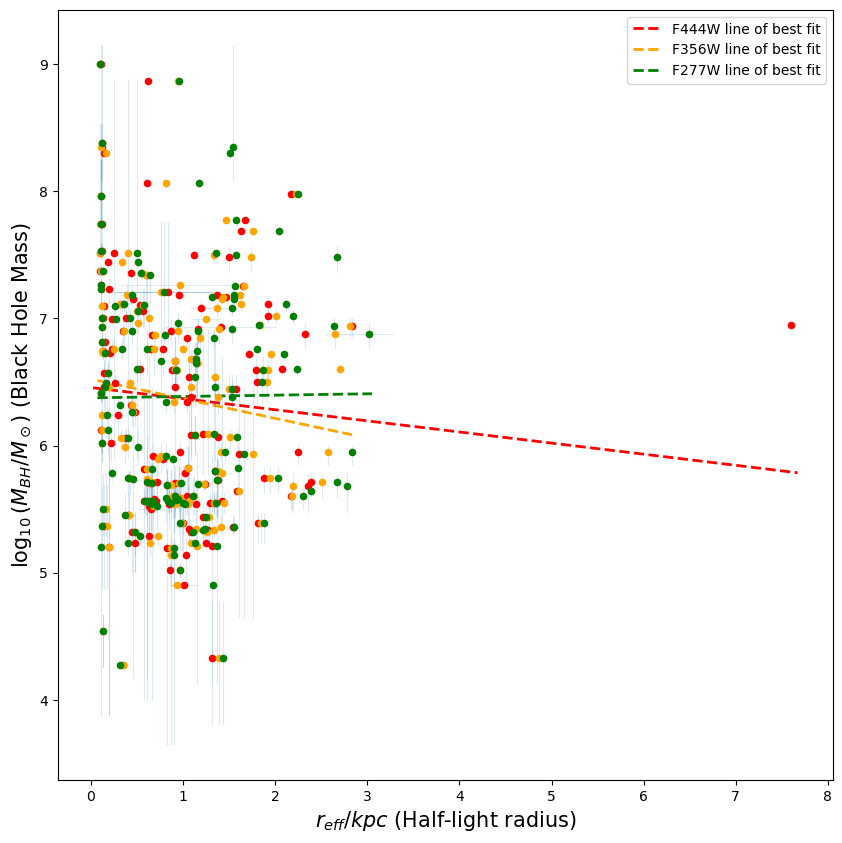

100%|██████████| 2000/2000 [00:08<00:00, 235.50it/s]



For plot below: 
Reduced chi squared = 1.17e+04
Scatter from fit = 0.889
Scatter (NMAD of normalised residuals) = 9.995
F444W Gradient = $0.08^{+0.11}_{-0.04}$
F444W Intercept = $6.22^{+0.14}_{-0.11}$


100%|██████████| 2000/2000 [00:07<00:00, 282.10it/s]



For plot below: 
Reduced chi squared = 1.08e+04
Scatter from fit = 0.895
Scatter (NMAD of normalised residuals) = 9.618
F356W Gradient = $0.08^{+0.11}_{-0.04}$
F356W Intercept = $6.23^{+0.14}_{-0.11}$


100%|██████████| 2000/2000 [00:06<00:00, 319.39it/s]



For plot below: 
Reduced chi squared = 4.08e+04
Scatter from fit = 0.898
Scatter (NMAD of normalised residuals) = 9.585
F277W Gradient = $-0.02^{+0.11}_{-0.04}$
F277W Intercept = $6.41^{+0.14}_{-0.11}$


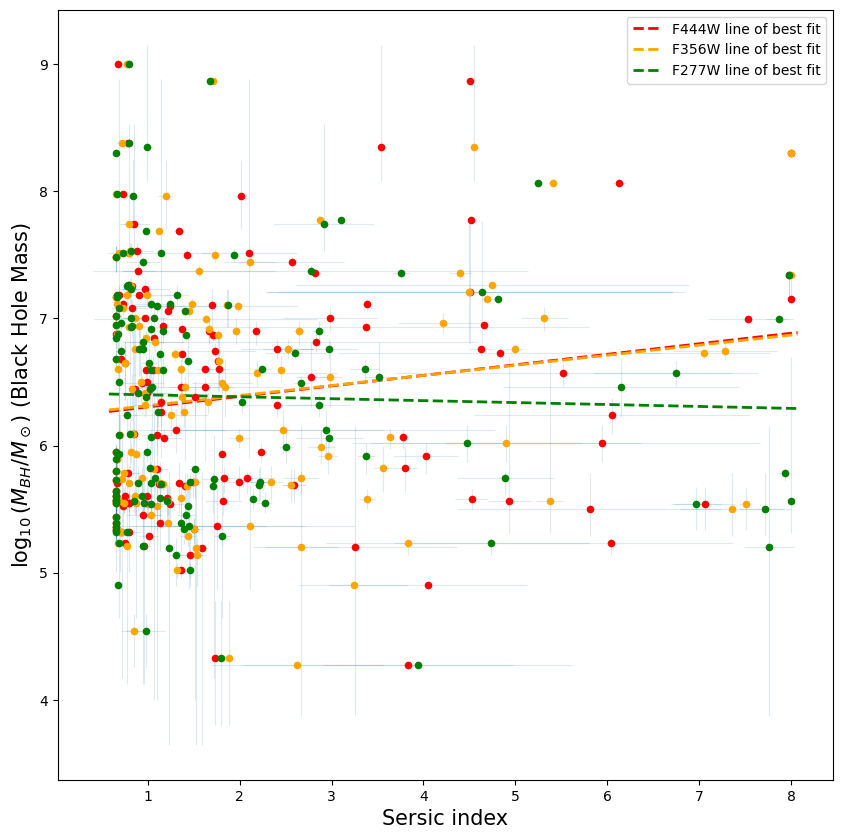

In [220]:
if __name__ == "__main__":
    
    stellar_tab = open_fits_table("/nvme/scratch/work/alberttg/Summer_project/Data_products/ProSpect_stellar_only_galaxy_table.fits")

    AGN_tab = open_fits_table("/nvme/scratch/work/alberttg/Summer_project/Data_products/ProSpect_stellar_AGN_galaxy_table.fits")

    combined_SED_tables = join(
        stellar_tab,
        AGN_tab,
        keys="SURVEY_ID",
        table_names=["stellar", "AGN"],
        uniq_col_name="{col_name}_{table_name}",
    )
    
    #plot_stellar_masses(combined_SED_tables)

    #bhm_vs_sm_plot(stellar_tab, AGN_tab)

    #time_evolution_SED_data(AGN_tab)


    morphology_tab = open_csv_table("/nvme/scratch/work/alberttg/Summer_project/csv_tables/All_morphology_table.csv")
    galaxy_tab = open_fits_table("/nvme/scratch/work/alberttg/Summer_project/Ha_and_NII_broad_line_data.fits")

    morphology_and_galaxy_table = join(
                galaxy_tab,
                morphology_tab,
                keys=["SURVEY_ID"]
    )

    bhm_vs_morph(morphology_and_galaxy_table)

    # TODO: bhsmr_vs_morph(morphology_and_galaxy_table) # This needs to be a DIC filtered table

    # TODO: time_evolution_morphology(table)